In [97]:
#import the necessaey libraries
%pip install matplotlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler





Note: you may need to restart the kernel to use updated packages.


In [98]:
import os

# loading the dataset
test_features = pd.read_csv("test_set_features.csv")
train_Features = pd.read_csv("training_set_features.csv")
train_labels = pd.read_csv("training_set_labels.csv")
submission = pd.read_csv("submission_format.csv")

In [99]:
#Exploring the dataset
print("test_features Shape:", test_features.shape)
print("train_Features Shape:", train_Features.shape)
print("train_labels Shape:", train_labels.shape)
print("submission Shape:", submission.shape)

test_features Shape: (26708, 36)
train_Features Shape: (26707, 36)
train_labels Shape: (26707, 3)
submission Shape: (26708, 3)


In [100]:
merge_traindata = pd.merge(train_Features, train_labels, on='respondent_id')
print("Merged training data shape:", merge_traindata.shape)
merge_traindata.head()

Merged training data shape: (26707, 38)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [101]:
# Confirm merge did not lose rows
print("Train features rows:", len(train_Features))
print("Train labels rows:", len(train_labels))
print("Merged rows:", len(merge_traindata))

Train features rows: 26707
Train labels rows: 26707
Merged rows: 26707


In [102]:
summary_table = pd.DataFrame({
    "column": merge_traindata.columns,
    "dtype": merge_traindata.dtypes.values,
    "missing_count": merge_traindata.isnull().sum().values,
    "missing_percent": (merge_traindata.isnull().mean() * 100).values,
    "n_unique": merge_traindata.nunique().values
}).sort_values(by="missing_percent", ascending=False)

summary_table.head(20)

,column,dtype,missing_count,missing_percent,n_unique
35,employment_occupation,object,13470,50.436215,23
34,employment_industry,object,13330,49.912008,21
15,health_insurance,float64,12274,45.957989,2
26,income_poverty,object,4423,16.561201,3
10,doctor_recc_h1n1,float64,2160,8.087767,2
11,doctor_recc_seasonal,float64,2160,8.087767,2
28,rent_or_own,object,2042,7.645936,2
29,employment_status,object,1463,5.477965,3
27,marital_status,object,1408,5.272026,2
23,education,object,1407,5.268282,4


In [103]:
#Classifying the Variable by Data Type
target_cols = ["h1n1_vaccine", "seasonal_vaccine"]
id_col = "respondent_id"
binary_cols = ["behavioral_antiviral_meds", "behavioral_avoidance", "behavioral_face_mask","behavioral_wash_hands",
               "behavioral_large_gatherings","behavioral_outside_home","behavioral_touch_face", "doctor_recc_h1n1", 
               "doctor_recc_seasonal","chronic_med_condition", "child_under_6_months", "health_worker","health_insurance"]

ordinal_cols = [
    "h1n1_concern", "h1n1_knowledge",
    "opinion_h1n1_vacc_effective", "opinion_h1n1_risk", "opinion_h1n1_sick_from_vacc",
    "opinion_seas_vacc_effective", "opinion_seas_risk", "opinion_seas_sick_from_vacc",
    "age_group", "education", "income_poverty"]

nominal_cols = [
    "race", "sex", "marital_status", "rent_or_own", "employment_status",
    "hhs_geo_region", "census_msa", "employment_industry", "employment_occupation"]

count_cols = ["household_adults", "household_children"]


all_known_cols = [id_col] + target_cols + binary_cols + ordinal_cols + nominal_cols + count_cols
unknown_cols = [col for col in merge_traindata.columns if col not in all_known_cols]

print("Unknown columns:", unknown_cols)


Unknown columns: []


In [104]:
#Analysing the target variable distribution

for target in target_cols:
    counts = merge_traindata[target].value_counts(dropna=False).sort_index()
    proportions = merge_traindata[target].value_counts(normalize=True).sort_index() * 100
    
    print(f"\nTarget: {target}")
    print("Counts:")
    print(counts)
    print("Percentages:")
    print(proportions.round(2))


Target: h1n1_vaccine
Counts:
h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64
Percentages:
h1n1_vaccine
0    78.75
1    21.25
Name: proportion, dtype: float64

Target: seasonal_vaccine
Counts:
seasonal_vaccine
0    14272
1    12435
Name: count, dtype: int64
Percentages:
seasonal_vaccine
0    53.44
1    46.56
Name: proportion, dtype: float64


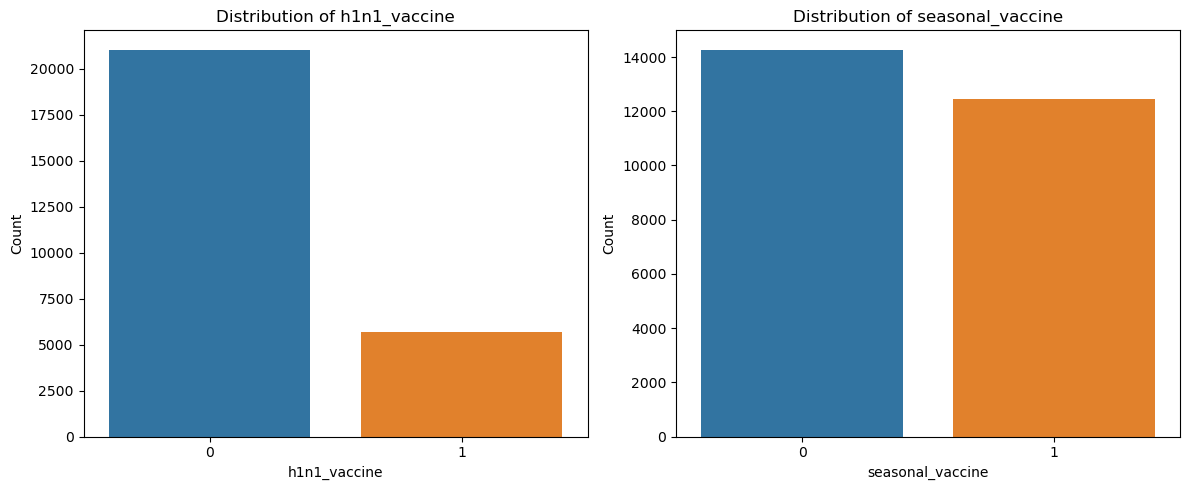

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, target in zip(axes, target_cols):
    sns.countplot(data=merge_traindata, x=target, ax=ax)
    ax.set_title(f"Distribution of {target}")
    ax.set_xlabel(target)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [106]:
#Studying the missing data
missing_report = (merge_traindata.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index())


missing_report.columns = ["column", "missing_percent"]
print(missing_report.head(20).round(2))

                         column  missing_percent
0         employment_occupation            50.44
1           employment_industry            49.91
2              health_insurance            45.96
3                income_poverty            16.56
4              doctor_recc_h1n1             8.09
5          doctor_recc_seasonal             8.09
6                   rent_or_own             7.65
7             employment_status             5.48
8                marital_status             5.27
9                     education             5.27
10        chronic_med_condition             3.64
11         child_under_6_months             3.07
12                health_worker             3.01
13  opinion_seas_sick_from_vacc             2.01
14            opinion_seas_risk             1.92
15  opinion_seas_vacc_effective             1.73
16  opinion_h1n1_sick_from_vacc             1.48
17  opinion_h1n1_vacc_effective             1.46
18            opinion_h1n1_risk             1.45
19             house

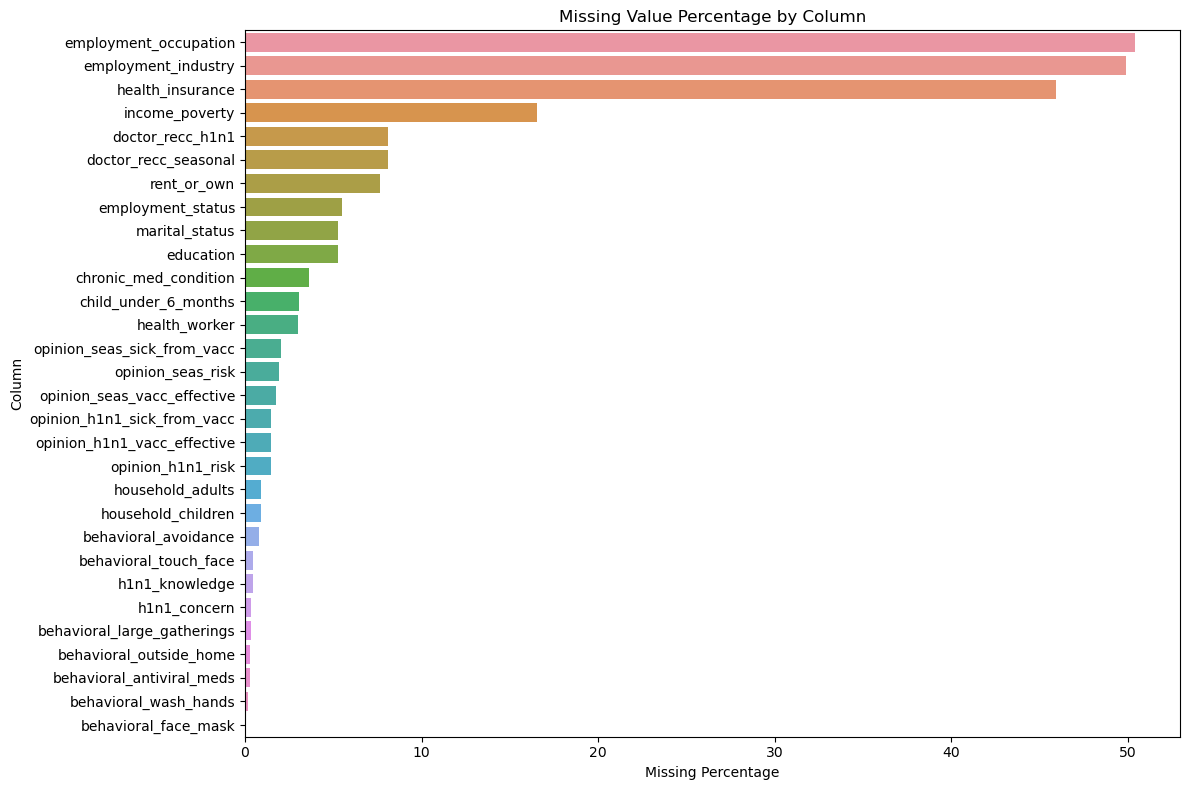

In [107]:
plt.figure(figsize=(12, 8))
missing_plot = missing_report[missing_report["missing_percent"] > 0]

sns.barplot(
    data=missing_plot,
    y="column",
    x="missing_percent"
)

plt.title("Missing Value Percentage by Column")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [108]:
#Inspect Categorical Distribution 
def plot_categorical_distribution(df, column, top_n=None):
    plt.figure(figsize=(10, 5))
    
    value_counts = df[column].value_counts(dropna=False)
    if top_n is not None:
        value_counts = value_counts.head(top_n)
    
    sns.barplot(x=value_counts.index.astype(str), y=value_counts.values)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

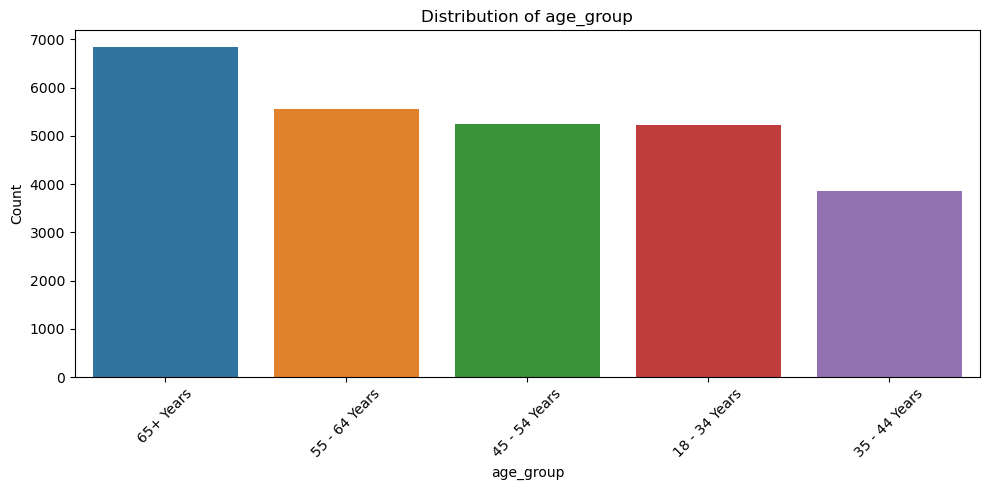

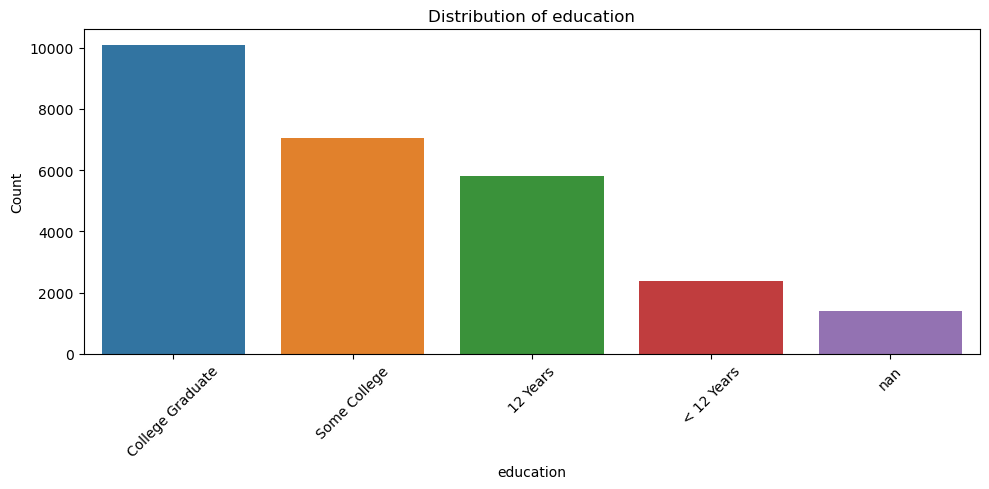

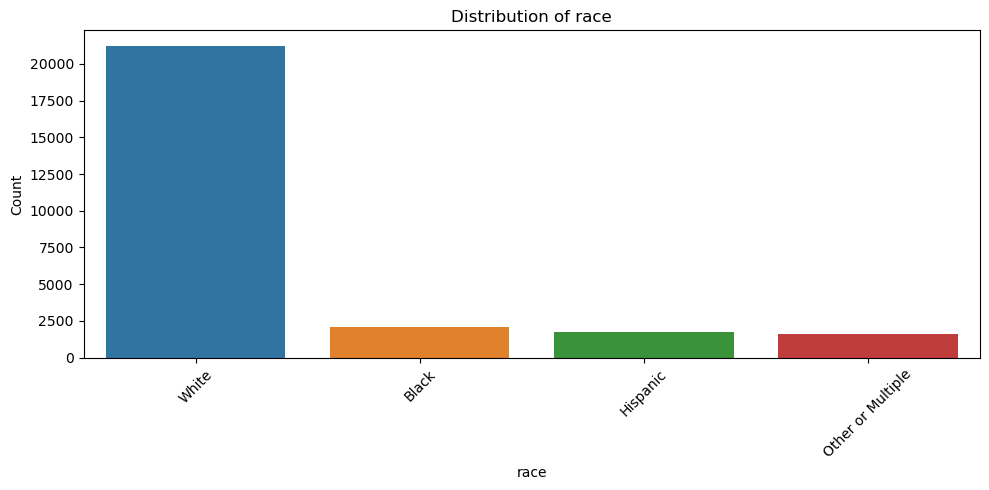

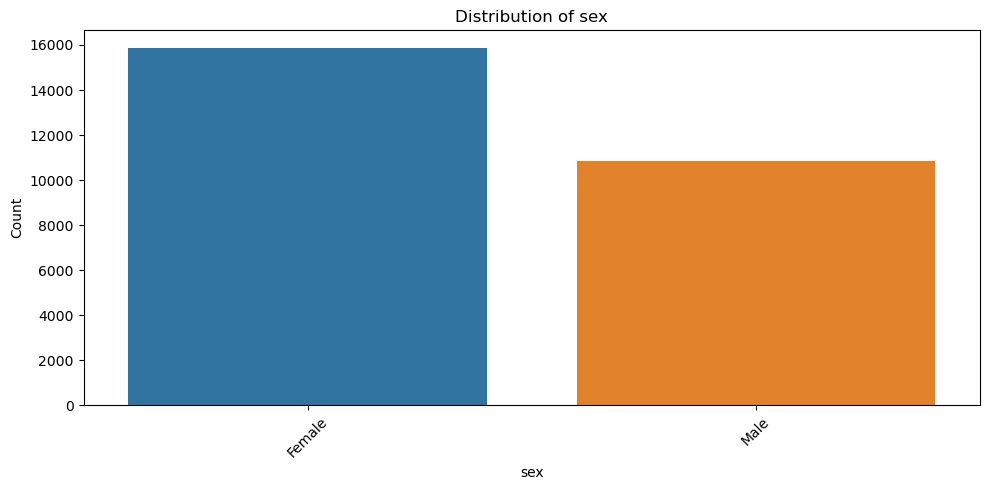

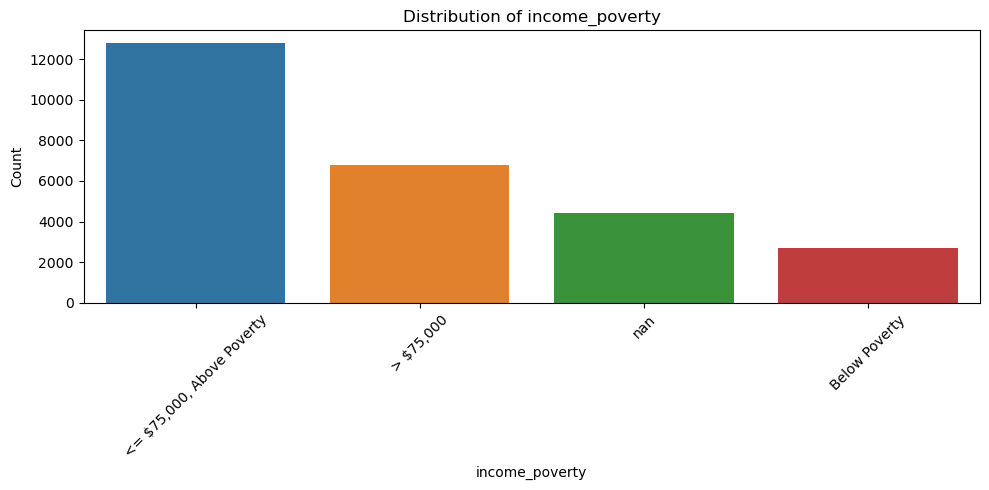

In [109]:
plot_categorical_distribution(merge_traindata, "age_group")
plot_categorical_distribution(merge_traindata, "education")
plot_categorical_distribution(merge_traindata, "race")
plot_categorical_distribution(merge_traindata, "sex")
plot_categorical_distribution(merge_traindata, "income_poverty")

In [110]:
# 9A. FEATURE vs TARGET RATE
temp = merge_traindata[["age_group", "h1n1_vaccine"]].copy()
temp.head()

,age_group,h1n1_vaccine
0,55 - 64 Years,0
1,35 - 44 Years,0
2,18 - 34 Years,0
3,65+ Years,0
4,45 - 54 Years,0


In [111]:
temp.isnull().sum()
temp["age_group"] = temp["age_group"].fillna("Missing")
temp.head()

,age_group,h1n1_vaccine
0,55 - 64 Years,0
1,35 - 44 Years,0
2,18 - 34 Years,0
3,65+ Years,0
4,45 - 54 Years,0


In [112]:
temp.groupby("age_group")["h1n1_vaccine"]

In [113]:
temp.groupby("age_group")["h1n1_vaccine"].mean()

age_group
18 - 34 Years    0.190029
35 - 44 Years    0.197765
45 - 54 Years    0.194731
55 - 64 Years    0.242855
65+ Years        0.226655
Name: h1n1_vaccine, dtype: float64

In [114]:
temp.groupby("age_group")["h1n1_vaccine"].mean().sort_values(ascending=False)

age_group
55 - 64 Years    0.242855
65+ Years        0.226655
35 - 44 Years    0.197765
45 - 54 Years    0.194731
18 - 34 Years    0.190029
Name: h1n1_vaccine, dtype: float64

In [115]:
rate_table = (
    temp.groupby("age_group")["h1n1_vaccine"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

rate_table

,age_group,h1n1_vaccine
0,55 - 64 Years,0.242855
1,65+ Years,0.226655
2,35 - 44 Years,0.197765
3,45 - 54 Years,0.194731
4,18 - 34 Years,0.190029


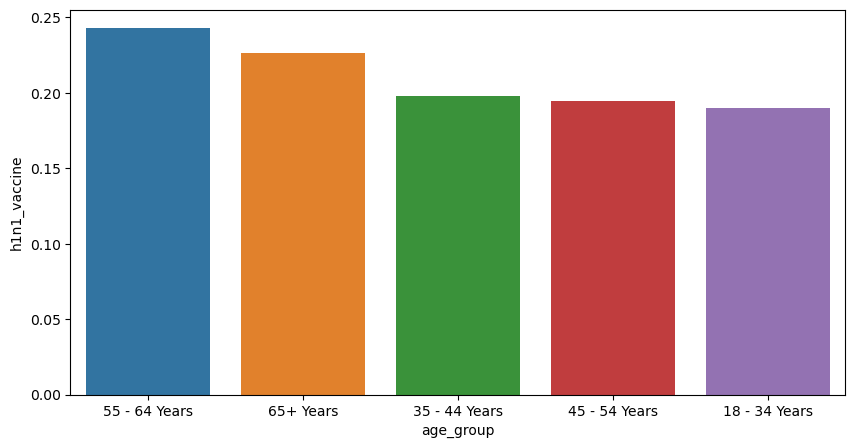

In [116]:
plt.figure(figsize=(10, 5))
sns.barplot(data=rate_table, x="age_group", y="h1n1_vaccine")
plt.show()

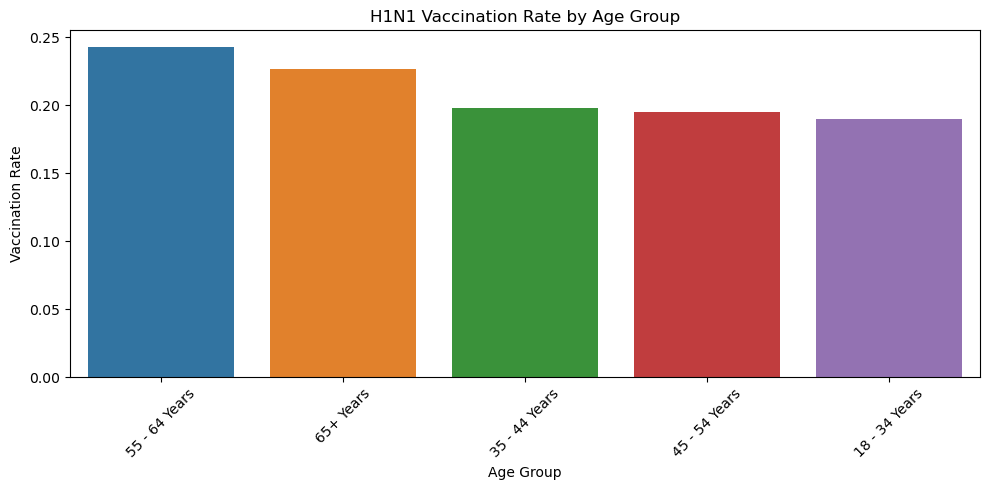

In [117]:
plt.figure(figsize=(10, 5))
sns.barplot(data=rate_table, x="age_group", y="h1n1_vaccine")

plt.title("H1N1 Vaccination Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Vaccination Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [118]:
# 9B. FEATURE vs TARGET RATE
temp = merge_traindata[["age_group", "seasonal_vaccine"]].copy()
temp = temp.fillna("Missing")
temp.head()


,age_group,seasonal_vaccine
0,55 - 64 Years,0
1,35 - 44 Years,1
2,18 - 34 Years,0
3,65+ Years,1
4,45 - 54 Years,0


In [119]:
temp.groupby("age_group")["seasonal_vaccine"].mean()

age_group
18 - 34 Years    0.284564
35 - 44 Years    0.362526
45 - 54 Years    0.401298
55 - 64 Years    0.511235
65+ Years        0.673681
Name: seasonal_vaccine, dtype: float64

In [120]:
temp.groupby("age_group")["seasonal_vaccine"].mean().sort_values(ascending=False)


age_group
65+ Years        0.673681
55 - 64 Years    0.511235
45 - 54 Years    0.401298
35 - 44 Years    0.362526
18 - 34 Years    0.284564
Name: seasonal_vaccine, dtype: float64

In [121]:
rate_table = (
    temp.groupby("age_group")["seasonal_vaccine"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

rate_table

,age_group,seasonal_vaccine
0,65+ Years,0.673681
1,55 - 64 Years,0.511235
2,45 - 54 Years,0.401298
3,35 - 44 Years,0.362526
4,18 - 34 Years,0.284564


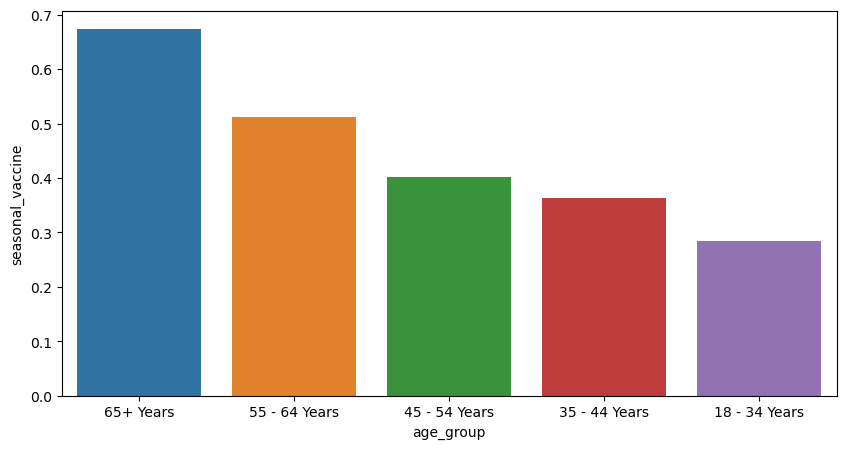

In [122]:
plt.figure(figsize=(10, 5))
sns.barplot(data=rate_table, x="age_group", y="seasonal_vaccine")
plt.show()

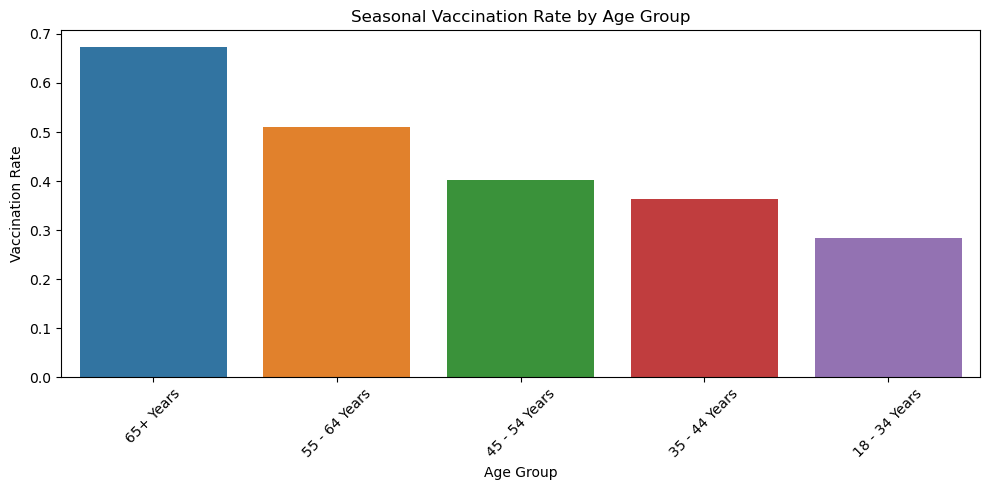

In [123]:
plt.figure(figsize=(10, 5))
sns.barplot(data=rate_table, x="age_group", y="seasonal_vaccine")

plt.title("Seasonal Vaccination Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Vaccination Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [145]:
temp = merge_traindata[["doctor_recc_h1n1", "h1n1_vaccine"]].copy()
temp.head()
temp.groupby("doctor_recc_h1n1")["h1n1_vaccine"].mean()
temp.groupby("doctor_recc_h1n1")["h1n1_vaccine"].mean().sort_values(ascending=False)
     

    

    
    

doctor_recc_h1n1
1.0    0.532359
0.0    0.136371
Name: h1n1_vaccine, dtype: float64

In [146]:
rate_table = (
    temp.groupby("doctor_recc_h1n1")["h1n1_vaccine"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

rate_table

,doctor_recc_h1n1,h1n1_vaccine
0,1.0,0.532359
1,0.0,0.136371


In [147]:
print(type(rate_table))
print(rate_table.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['doctor_recc_h1n1', 'h1n1_vaccine'], dtype='object')


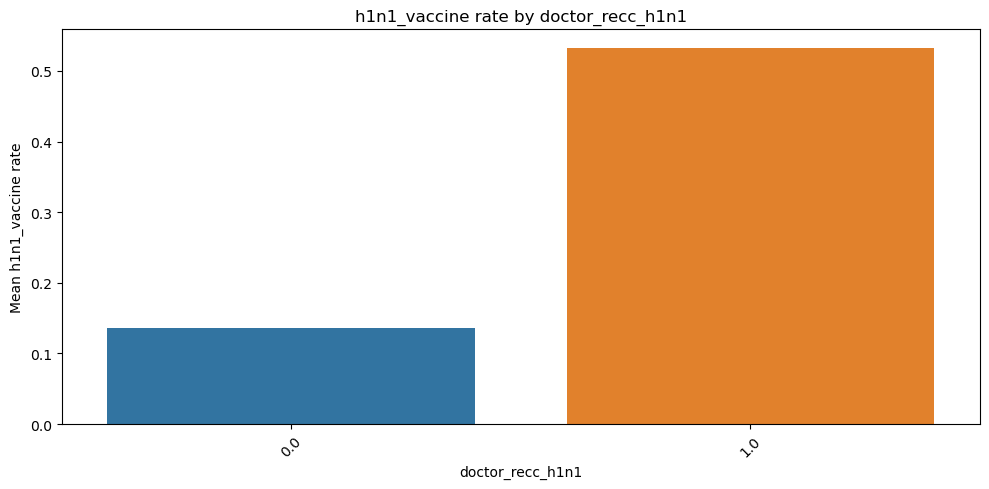

In [148]:
plt.figure(figsize=(10, 5))
sns.barplot(data=rate_table, x="doctor_recc_h1n1", y="h1n1_vaccine")
plt.title("h1n1_vaccine rate by doctor_recc_h1n1")
plt.xlabel("doctor_recc_h1n1")
plt.ylabel("Mean h1n1_vaccine rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()